In [2]:
import tensorflow as tf
import cv2
import os

print("PixelGuard Yapay Zeka Stüdyosu Aktif! 🚀")
print("TensorFlow Versiyonu:", tf.__version__)
# Veri setini indir ve otomatik olarak zipten çıkar
!kaggle datasets download -d marcozuppelli/stegoimagesdataset --unzip --force

PixelGuard Yapay Zeka Stüdyosu Aktif! 🚀
TensorFlow Versiyonu: 2.21.0
Dataset URL: https://www.kaggle.com/datasets/marcozuppelli/stegoimagesdataset
License(s): DbCL-1.0




  0%|          | 0.00/1.51G [00:00<?, ?B/s]
  0%|          | 1.00M/1.51G [00:00<17:33, 1.54MB/s]
  0%|          | 2.00M/1.51G [00:00<11:12, 2.40MB/s]
  0%|          | 3.00M/1.51G [00:01<09:03, 2.98MB/s]
  0%|          | 4.00M/1.51G [00:01<08:15, 3.26MB/s]
  0%|          | 5.00M/1.51G [00:01<07:42, 3.49MB/s]
  0%|          | 6.00M/1.51G [00:01<07:19, 3.67MB/s]
  0%|          | 7.00M/1.51G [00:02<07:04, 3.80MB/s]
  1%|          | 8.00M/1.51G [00:02<06:55, 3.88MB/s]
  1%|          | 9.00M/1.51G [00:02<06:48, 3.94MB/s]
  1%|          | 10.0M/1.51G [00:03<07:06, 3.77MB/s]
  1%|          | 11.0M/1.51G [00:03<06:37, 4.05MB/s]
  1%|          | 12.0M/1.51G [00:03<06:37, 4.04MB/s]
  1%|          | 13.0M/1.51G [00:03<06:40, 4.01MB/s]
  1%|          | 14.0M/1.51G [00:04<06:55, 3.86MB/s]
  1%|          | 16.0M/1.51G [00:04<05:22, 4.98MB/s]
  1%|          | 17.0M/1.51G [00:04<05:13, 5.11MB/s]
  1%|          | 18.0M/1.51G [00:04<05:04, 5.26MB/s]
  1%|          | 19.0M/1.51G [00:04<04:59, 5.34MB/s]
 

EDA Aktif: Veri Seti Gözetleme Ekranı Açılıyor...



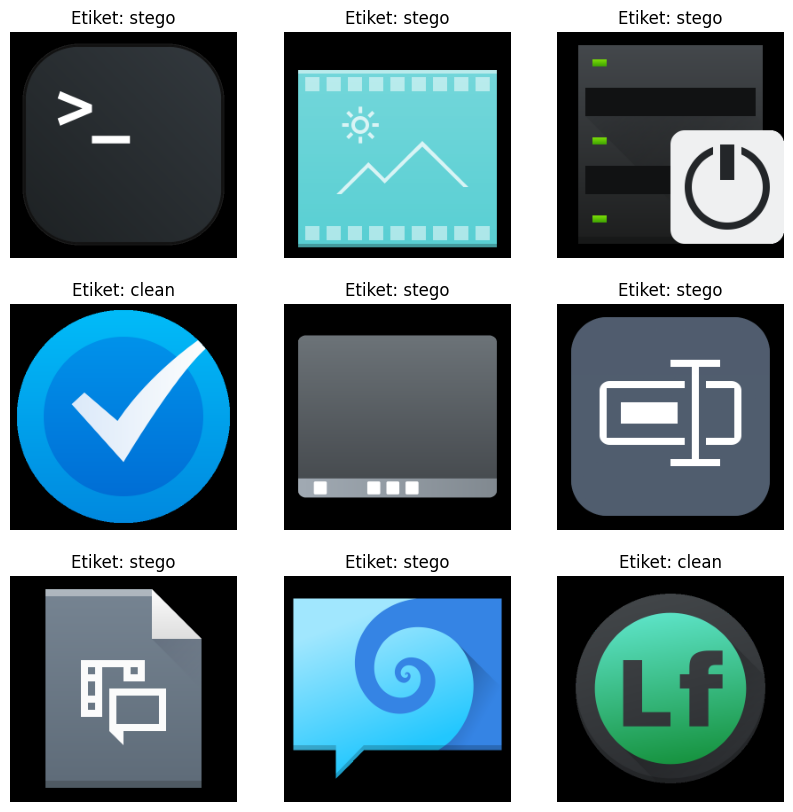

In [16]:
import matplotlib.pyplot as plt
import numpy as np

print("EDA Aktif: Veri Seti Gözetleme Ekranı Açılıyor...\n")

# Boru hattımızdan sadece 1 paket (32 resimlik) veri çekiyoruz
for images, labels in train_dataset.take(1):
    
    plt.figure(figsize=(10, 10))
    
    # Sadece ilk 9 resmi ekrana basalım
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        
        # Resimler 0-1 arasında olduğu için (Normalizasyon), 
        # ekranda göstermek için onları tekrar 0-255 formatına çekmemiz lazım.
        resim = images[i].numpy() 
        
        plt.imshow(resim)
        
        # Sınıf adını (0: Clean, 1: Stego) başlık olarak yazalım
        gercek_sinif = class_names[labels[i]]
        plt.title(f"Etiket: {gercek_sinif}")
        plt.axis("off")
        
    plt.show()

In [12]:
BATCH_SIZE = 32
IMG_SIZE = (256, 256)

print("Dedektif Modu Aktif: Gerçek klasörler aranıyor...\n")

# Eğer 'train' klasörünün içinde sadece tek bir klasör varsa (Matruşka durumu), bir alt kata in.
train_icerik = os.listdir("train")
if len(train_icerik) == 1 and os.path.isdir(os.path.join("train", train_icerik[0])):
    train_dir = os.path.join("train", train_icerik[0])
else:
    train_dir = "train"

# Aynı matruşka şakasını 'val' klasörü için de çözelim
val_icerik = os.listdir("val")
if len(val_icerik) == 1 and os.path.isdir(os.path.join("val", val_icerik[0])):
    val_dir = os.path.join("val", val_icerik[0])
else:
    val_dir = "val"

print(f"Doğru Train Yolu: {train_dir}")
print(f"Doğru Validation Yolu: {val_dir}\n")

# 1. Eğitim ve Validasyon Verilerini Gerçek Yollardan Çekme
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, 
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir, 
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

# İşte burası çok kritik! Sınıfların doğru geldiğini buradan anlayacağız.
class_names = train_dataset.class_names
print(f"\nBulunan Gerçek Sınıflar: {class_names}")

# Normalizasyon (0-1 arası pikseller)
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))

print("\nAşama 1 Tamamlandı: Matruşka şakası bozuldu, resimler hazır! 🚀")

Dedektif Modu Aktif: Gerçek klasörler aranıyor...

Doğru Train Yolu: train\train
Doğru Validation Yolu: val\val

Found 16000 files belonging to 2 classes.
Found 8000 files belonging to 2 classes.

Bulunan Gerçek Sınıflar: ['clean', 'stego']

Aşama 1 Tamamlandı: Matruşka şakası bozuldu, resimler hazır! 🚀


In [17]:
from tensorflow.keras import models, layers, Input

print("Yapay Zekanın Beyni (CNN) Örülüyor (Sıfır Uyarı Versiyonu)...\n")

model = models.Sequential([
    # YENİ STANDART: Resmi içeri alma işini ayrı bir katman yaptık
    Input(shape=(256, 256, 3)),
    
    # 1. GÖZ Katmanı (Artık input_shape yok, tertemiz)
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 2. GÖZ Katmanı
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 3. GÖZ Katmanı
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Matrisleri Düzleştirme
    layers.Flatten(),

    # BEYİN Katmanı
    layers.Dense(64, activation='relu'),
    
    # ÇIKIŞ Katmanı (2 nöron: Clean ve Stego)
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

model.summary()

Yapay Zekanın Beyni (CNN) Örülüyor (Sıfır Uyarı Versiyonu)...



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,742,914 (14.28 MB)

 Trainable params: 3,742,914 (14.28 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Temiz resimler (0) azınlıkta olduğu için onları bulmanın ödülünü 3 katına çıkarıyoruz
sinif_agirliklari = {
    0: 3.0, 
    1: 1.0  
}

print("Aşama 3 (Rövanş): Puanlama sistemi değiştirildi. Eğitim başlıyor...\n")

EPOCHS = 5 

# Model eğitilirken hafızasındaki ağırlıkları bu yeni kurala göre güncelleyecek
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    class_weight=sinif_agirliklari
)

print("\nAşama 3: Gerçek ve Adil Eğitim Tamamlandı! 🎉")

Aşama 3 (Rövanş): Puanlama sistemi değiştirildi. Eğitim başlıyor...

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 576s 1s/step - accuracy: 0.4611 - loss: 1.0667 - val_accuracy: 0.7500 - val_loss: 0.6931
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 256s 512ms/step - accuracy: 0.4786 - loss: 1.0399 - val_accuracy: 0.7500 - val_loss: 0.6928
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 250s 499ms/step - accuracy: 0.5010 - loss: 1.0399 - val_accuracy: 0.7500 - val_loss: 0.6929
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 250s 499ms/step - accuracy: 0.4579 - loss: 1.0399 - val_accuracy: 0.2500 - val_loss: 0.6935
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 251s 501ms/step - accuracy: 0.4831 - loss: 1.0399 - val_accuracy: 0.7500 - val_loss: 0.6924

Aşama 3: Gerçek ve Adil Eğitim Tamamlandı! 🎉


In [15]:
print("Aşama 3: Eğitim Başlıyor! Yapay Zeka Staja Girdi...\n")

# Modelin veri seti üzerinden kaç tam tur geçeceğini belirliyoruz.
# CPU kullandığımız için şimdilik 5 tur (Epoch) yeterli olacaktır.
EPOCHS = 5 

# Büyük antrenman başlıyor (İşlemcin biraz ısınabilir, normaldir)
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

print("\nAşama 3: Eğitim Tamamlandı! 🎉 Dedektifimiz artık mezun oldu!")

Aşama 3: Eğitim Başlıyor! Yapay Zeka Staja Girdi...

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 843s 2s/step - accuracy: 0.7467 - loss: 0.5784 - val_accuracy: 0.7500 - val_loss: 0.5634
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 626s 1s/step - accuracy: 0.7500 - loss: 0.5657 - val_accuracy: 0.7500 - val_loss: 0.5626
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 426s 852ms/step - accuracy: 0.7500 - loss: 0.5636 - val_accuracy: 0.7500 - val_loss: 0.5635
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 272s 544ms/step - accuracy: 0.7500 - loss: 0.5638 - val_accuracy: 0.7500 - val_loss: 0.5630
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 338s 675ms/step - accuracy: 0.7500 - loss: 0.5636 - val_accuracy: 0.7500 - val_loss: 0.5623

Aşama 3: Eğitim Tamamlandı! 🎉 Dedektifimiz artık mezun oldu!
